In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Bisection Method

In [27]:
def func(x):
    return x**3-(7*x**2)+14*x-5

def bisect_method(func,x0,x1,tol=1e-8):
    '''
    Function to find the roots with the bisection method. Takes two starting arguments: x0 and x1, a tolerance, and any function one desires 
    (that has a root). The default tolerance is < 1e-8
    '''
    #Check with the given arguements for the root and if they correctly bracket the root
    y0 = func(x0)
    y1 = func(x1)

    if y0*y1 > 0:
        raise ValueError("Oops, these guesses don't bracket the root, so this method will not work. Try again.")
    if y0 == 0:
        print(f"Your initial root guess x0 = {x0} is correct. That means this process took 0 iterations.")
        return x0
    if y1 == 0:
        print(f"Your initial root guess x1 = {x1} is correct. That means this process took 0 iterations.")
        return x1

    #Want the loop to be a while loop so it breaks automatically, so I set the error to some large value greater than the tolerance. 
    e = 10
    iteration = 0 #this is to count how many iterations it takes to find the root
    x_old = None #GPT helped with this because I don't have an "old x" from initial guesses. This will help with the error calc in loop. 

    #Now actually start the bisection method
    while e > tol:
        print(f"[Iteration {iteration}] Calculating new root with brackets ({x0}, {x1})")
        x_new = (x0+x1)/2
        y_new = func(x_new)
        #Check for root found 
        if y_new == 0:
            print(f"Congrats, the root is {x_new}.")
            return x_new
        
        #This is the relative error calculation
        if x_old is not None:
            e = abs(x_new - x_old) / max(abs(x_old), 1.0) #ran into divide by zero issue, but this fixes it
        
        #This is where it updates the bracketing to continue
        if y0 * y_new < 0:
            print(f"Updating upper bracket: {x1} --> {x_new}. Relative error is {e}.")
            x1 = x_new
        else:
            print(f"Updating lower bracket: {x0} --> {x_new}. Relative error is {e}.")
            x0 = x_new
            
        x_old = x_new
        iteration += 1 

    print(f"Converged in {iteration} iteration(s) with a final root of {x_new} and relative error of {e}.")  

    return x_new

In [3]:
bisect_method(func,0,1)

[Iteration 0] Calculating new root with brackets (0, 1)
Updating uppper bracket: 1 --> 0.5. Relative error is 10.
[Iteration 1] Calculating new root with brackets (0, 0.5)
Updating lower bracket: 0 --> 0.25. Relative error is 0.25.
[Iteration 2] Calculating new root with brackets (0.25, 0.5)
Updating lower bracket: 0.25 --> 0.375. Relative error is 0.125.
[Iteration 3] Calculating new root with brackets (0.375, 0.5)
Updating lower bracket: 0.375 --> 0.4375. Relative error is 0.0625.
[Iteration 4] Calculating new root with brackets (0.4375, 0.5)
Updating uppper bracket: 0.5 --> 0.46875. Relative error is 0.03125.
[Iteration 5] Calculating new root with brackets (0.4375, 0.46875)
Updating lower bracket: 0.4375 --> 0.453125. Relative error is 0.015625.
[Iteration 6] Calculating new root with brackets (0.453125, 0.46875)
Updating uppper bracket: 0.46875 --> 0.4609375. Relative error is 0.0078125.
[Iteration 7] Calculating new root with brackets (0.453125, 0.4609375)
Updating uppper bracket

0.4531817212700844

## Checking sensitivity to BM by initial conditions

In [4]:
bisect_method(func,-5,3)

[Iteration 0] Calculating new root with brackets (-5, 3)
Updating lower bracket: -5 --> -1.0. Relative error is 10.
[Iteration 1] Calculating new root with brackets (-1.0, 3)
Updating uppper bracket: 3 --> 1.0. Relative error is 2.0.
[Iteration 2] Calculating new root with brackets (-1.0, 1.0)
Updating lower bracket: -1.0 --> 0.0. Relative error is 1.0.
[Iteration 3] Calculating new root with brackets (0.0, 1.0)
Updating uppper bracket: 1.0 --> 0.5. Relative error is 0.5.
[Iteration 4] Calculating new root with brackets (0.0, 0.5)
Updating lower bracket: 0.0 --> 0.25. Relative error is 0.25.
[Iteration 5] Calculating new root with brackets (0.25, 0.5)
Updating lower bracket: 0.25 --> 0.375. Relative error is 0.125.
[Iteration 6] Calculating new root with brackets (0.375, 0.5)
Updating lower bracket: 0.375 --> 0.4375. Relative error is 0.0625.
[Iteration 7] Calculating new root with brackets (0.4375, 0.5)
Updating uppper bracket: 0.5 --> 0.46875. Relative error is 0.03125.
[Iteration 8]

0.4531817212700844

In [23]:
bisect_method(func,-12,20)

[Iteration 0] Calculating new root with brackets (-12, 20)
Updating uppper bracket: 20 --> 4.0. Relative error is 10.
[Iteration 1] Calculating new root with brackets (-12, 4.0)
Updating lower bracket: -12 --> -4.0. Relative error is 2.0.
[Iteration 2] Calculating new root with brackets (-4.0, 4.0)
Updating lower bracket: -4.0 --> 0.0. Relative error is 1.0.
[Iteration 3] Calculating new root with brackets (0.0, 4.0)
Updating uppper bracket: 4.0 --> 2.0. Relative error is 2.0.
[Iteration 4] Calculating new root with brackets (0.0, 2.0)
Updating uppper bracket: 2.0 --> 1.0. Relative error is 0.5.
[Iteration 5] Calculating new root with brackets (0.0, 1.0)
Updating uppper bracket: 1.0 --> 0.5. Relative error is 0.5.
[Iteration 6] Calculating new root with brackets (0.0, 0.5)
Updating lower bracket: 0.0 --> 0.25. Relative error is 0.25.
[Iteration 7] Calculating new root with brackets (0.25, 0.5)
Updating lower bracket: 0.25 --> 0.375. Relative error is 0.125.
[Iteration 8] Calculating ne

0.4531817212700844

In [7]:
bisect_method(func,-0.5,0.5)

[Iteration 0] Calculating new root with brackets (-0.5, 0.5)
Updating lower bracket: -0.5 --> 0.0. Relative error is 10.
[Iteration 1] Calculating new root with brackets (0.0, 0.5)
Updating lower bracket: 0.0 --> 0.25. Relative error is 0.25.
[Iteration 2] Calculating new root with brackets (0.25, 0.5)
Updating lower bracket: 0.25 --> 0.375. Relative error is 0.125.
[Iteration 3] Calculating new root with brackets (0.375, 0.5)
Updating lower bracket: 0.375 --> 0.4375. Relative error is 0.0625.
[Iteration 4] Calculating new root with brackets (0.4375, 0.5)
Updating uppper bracket: 0.5 --> 0.46875. Relative error is 0.03125.
[Iteration 5] Calculating new root with brackets (0.4375, 0.46875)
Updating lower bracket: 0.4375 --> 0.453125. Relative error is 0.015625.
[Iteration 6] Calculating new root with brackets (0.453125, 0.46875)
Updating uppper bracket: 0.46875 --> 0.4609375. Relative error is 0.0078125.
[Iteration 7] Calculating new root with brackets (0.453125, 0.4609375)
Updating upp

0.4531817212700844

In [8]:
bisect_method(func,0.44,0.46)

[Iteration 0] Calculating new root with brackets (0.44, 0.46)
Updating lower bracket: 0.44 --> 0.45. Relative error is 10.
[Iteration 1] Calculating new root with brackets (0.45, 0.46)
Updating uppper bracket: 0.46 --> 0.455. Relative error is 0.0050000000000000044.
[Iteration 2] Calculating new root with brackets (0.45, 0.455)
Updating lower bracket: 0.45 --> 0.4525. Relative error is 0.0025000000000000022.
[Iteration 3] Calculating new root with brackets (0.4525, 0.455)
Updating uppper bracket: 0.455 --> 0.45375. Relative error is 0.0012499999999999734.
[Iteration 4] Calculating new root with brackets (0.4525, 0.45375)
Updating lower bracket: 0.4525 --> 0.453125. Relative error is 0.0006249999999999867.
[Iteration 5] Calculating new root with brackets (0.453125, 0.45375)
Updating uppper bracket: 0.45375 --> 0.4534375. Relative error is 0.00031249999999999334.
[Iteration 6] Calculating new root with brackets (0.453125, 0.4534375)
Updating uppper bracket: 0.4534375 --> 0.45328124999999

0.45318171501159665

In [26]:
bisect_method(func,-150,200)

[Iteration 0] Calculating new root with brackets (-150, 200)
Updating uppper bracket: 200 --> 25.0. Relative error is 10.
[Iteration 1] Calculating new root with brackets (-150, 25.0)
Updating lower bracket: -150 --> -62.5. Relative error is 3.5.
[Iteration 2] Calculating new root with brackets (-62.5, 25.0)
Updating lower bracket: -62.5 --> -18.75. Relative error is 0.7.
[Iteration 3] Calculating new root with brackets (-18.75, 25.0)
Updating uppper bracket: 25.0 --> 3.125. Relative error is 1.1666666666666667.
[Iteration 4] Calculating new root with brackets (-18.75, 3.125)
Updating lower bracket: -18.75 --> -7.8125. Relative error is 3.5.
[Iteration 5] Calculating new root with brackets (-7.8125, 3.125)
Updating lower bracket: -7.8125 --> -2.34375. Relative error is 0.7.
[Iteration 6] Calculating new root with brackets (-2.34375, 3.125)
Updating lower bracket: -2.34375 --> 0.390625. Relative error is 1.1666666666666667.
[Iteration 7] Calculating new root with brackets (0.390625, 3.1

0.45318172706174664

# NR Method

In [9]:
def func(x):
    return x**3-(7*x**2)+14*x-5

def deriv_func(x):
    return 3*x**2-14*x+14

def NR_method(func,deriv_func,x0,tol=1e-8):
    '''
    NR method for a particular function defined earlier. I know there's a way to get the derivative symbolically, but for the purposes
    of this assignment, I decided to reduce flexibility and have the functions defined in advance. Takes one starting argument: x0, 
    a tolerance, and any function one desires (that has a root) with its derivative. The default tolerance is < 1e-8
    '''

    y0 = func(x0)
    if y0 == 0:
        print(f"Your initial root guess x0 = {x0} is correct. That means this process took 0 iterations.")
        return x0
    
    #Want the loop to be a while loop so it breaks automatically, so I set the error to some large value greater than the tolerance. 
    e = 10
    iteration = 0 #this is to count how many iterations it takes to find the root
    x_old = None #GPT helped with this because I don't have an "old x" from initial guesses. This will help with the error calc in loop. 

    #Now actually start the NR method
    while e > tol:
        print(f"[Iteration {iteration}] Calculating new root with {x0}.")
        x_new = x0-(func(x0)/deriv_func(x0))
        y_new = func(x_new)
        #Check for root found 
        # if y_new == 0:
        #     iteration += 1 
        #     print(f"Congrats, the root is {x_new} and it only took {iteration} iterations")
        #     return x_new
        
        #This is the relative error calculation
        if x_old is not None:
            e = abs(x_new - x_old) / max(abs(x_old), 1.0) #ran into divide by zero issue, but this fixes it
            
        x_old = x_new
        x0 = x_new
        print(f"Relative error is {e}")
        iteration += 1 
    print(f"Converged in {iteration} iteration(s) with a final root of {x_new} with relative error {e}.")  
    
    return x_new
        

In [10]:
NR_method(func,deriv_func,0)

[Iteration 0] Calculating new root with 0.
Relative error is 10
[Iteration 1] Calculating new root with 0.35714285714285715.
Relative error is 0.09030529014215799
[Iteration 2] Calculating new root with 0.44744814728501514.
Relative error is 0.005711287833180867
[Iteration 3] Calculating new root with 0.453159435118196.
Relative error is 2.2287658988484615e-05
[Iteration 4] Calculating new root with 0.4531817227771845.
Relative error is 3.3873348570523376e-10
Converged in 5 iteration(s) with a final root of 0.453181723115918 with relative error 3.3873348570523376e-10.


0.453181723115918

## Testing NR and Seeing If I Can Break It

In [11]:
NR_method(func,deriv_func,0.43)

[Iteration 0] Calculating new root with 0.43.
Relative error is 10
[Iteration 1] Calculating new root with 0.45282364933741087.
Relative error is 0.0003579863780035497
[Iteration 2] Calculating new root with 0.4531816357154144.
Relative error is 8.740049828315222e-08
[Iteration 3] Calculating new root with 0.4531817231159127.
Relative error is 5.2735593669694936e-15
Converged in 4 iteration(s) with a final root of 0.453181723115918 with relative error 5.2735593669694936e-15.


0.453181723115918

In [12]:
NR_method(func,deriv_func,1.7)

[Iteration 0] Calculating new root with 1.7.
Relative error is 10
[Iteration 1] Calculating new root with 4.782300884955749.
Relative error is 0.14999519719279802
[Iteration 2] Calculating new root with 4.064978720681519.
Relative error is 0.1259569262726894
[Iteration 3] Calculating new root with 3.5529664956605855.
Relative error is 0.1622833273508546
[Iteration 4] Calculating new root with 2.97637927077868.
Relative error is 0.3150460880797077
[Iteration 5] Calculating new root with 3.914075916679036.
Relative error is 0.12473941670881313
[Iteration 6] Calculating new root with 3.42583636987848.
Relative error is 0.23730418050503568
[Iteration 7] Calculating new root with 2.612871077580121.
Relative error is 0.2970085173012059
[Iteration 8] Calculating new root with 3.388916042231397.
Relative error is 0.28426070236356915
[Iteration 9] Calculating new root with 2.425580387815533.
Relative error is 0.3652887792671829
[Iteration 10] Calculating new root with 3.3116176866950893.
Relati

0.4531817231159179

In [13]:
NR_method(func,deriv_func,230)

[Iteration 0] Calculating new root with 230.
Relative error is 10
[Iteration 1] Calculating new root with 154.11337414948486.
Relative error is 0.328264587963356
[Iteration 2] Calculating new root with 103.52341088466169.
Relative error is 0.32577148031596354
[Iteration 3] Calculating new root with 69.79843607340771.
Relative error is 0.32208237444246285
[Iteration 4] Calculating new root with 47.317590050514106.
Relative error is 0.31666011355666074
[Iteration 5] Calculating new root with 32.33399661189079.
Relative error is 0.30876974921792694
[Iteration 6] Calculating new root with 22.35023658682397.
Relative error is 0.29745680039699623
[Iteration 7] Calculating new root with 15.702006723591431.
Relative error is 0.28158827635619266
[Iteration 8] Calculating new root with 11.280505714961972.
Relative error is 0.2600387527878756
[Iteration 9] Calculating new root with 8.347137078026758.
Relative error is 0.23214733707464527
[Iteration 10] Calculating new root with 6.409371433165811.

0.4531817231159179

In [14]:
NR_method(func,deriv_func,-2)

[Iteration 0] Calculating new root with -2.
Relative error is 10
[Iteration 1] Calculating new root with -0.7222222222222223.
Relative error is 0.7454087697506379
[Iteration 2] Calculating new root with 0.023186547528415535.
Relative error is 0.34211733395283656
[Iteration 3] Calculating new root with 0.3653038814812521.
Relative error is 0.0830409522156566
[Iteration 4] Calculating new root with 0.4483448336969087.
Relative error is 0.004821013341623881
[Iteration 5] Calculating new root with 0.4531658470385326.
Relative error is 1.587590551321849e-05
[Iteration 6] Calculating new root with 0.4531817229440458.
Relative error is 1.7187218315228847e-10
Converged in 7 iteration(s) with a final root of 0.453181723115918 with relative error 1.7187218315228847e-10.


0.453181723115918

In [15]:
NR_method(func,deriv_func,10000)

[Iteration 0] Calculating new root with 10000.
Relative error is 10
[Iteration 1] Calculating new root with 6667.444496300865.
Relative error is 0.3332166686116117
[Iteration 2] Calculating new root with 4445.740853090665.
Relative error is 0.33315835812464767
[Iteration 3] Calculating new root with 2964.6051298273087.
Relative error is 0.33307091972385244
[Iteration 4] Calculating new root with 1977.181372617676.
Relative error is 0.3329398235841866
[Iteration 5] Calculating new root with 1318.898955224407.
Relative error is 0.33274331756134456
[Iteration 6] Calculating new root with 880.0441413348466.
Relative error is 0.33244886910406457
[Iteration 7] Calculating new root with 587.4744617864193.
Relative error is 0.3320078940613277
[Iteration 8] Calculating new root with 392.4283029138983.
Relative error is 0.33134799730915376
[Iteration 9] Calculating new root with 262.39797065594814.
Relative error is 0.3303616622104259
[Iteration 10] Calculating new root with 175.71174090940656.


0.4531817231159179

In [16]:
NR_method(func,deriv_func,100)

[Iteration 0] Calculating new root with 100.
Relative error is 10
[Iteration 1] Calculating new root with 67.44967498427343.
Relative error is 0.321686656715944
[Iteration 2] Calculating new root with 45.75201454200547.
Relative error is 0.3160810797670539
[Iteration 3] Calculating new root with 31.290668384050427.
Relative error is 0.30793273321447834
[Iteration 4] Calculating new root with 21.655247344441914.
Relative error is 0.2962684976112094
[Iteration 5] Calculating new root with 15.239479748304976.
Relative error is 0.27994568671563347
[Iteration 6] Calculating new root with 10.97325312497675.
Relative error is 0.2578562403598273
[Iteration 7] Calculating new root with 8.14373132965352.
Relative error is 0.22941422245031354
[Iteration 8] Calculating new root with 6.275443538816799.
Relative error is 0.19545823849121313
[Iteration 9] Calculating new root with 5.048856398968603.
Relative error is 0.15961669117856928
[Iteration 10] Calculating new root with 4.242974646329488.
Rela

0.45318172311591787

In [17]:
NR_method(func,deriv_func,-34.2)

[Iteration 0] Calculating new root with -34.2.
Relative error is 10
[Iteration 1] Calculating new root with -22.0369880951191.
Relative error is 0.36760315116615905
[Iteration 2] Calculating new root with -13.936121829142186.
Relative error is 0.38664512942919343
[Iteration 3] Calculating new root with -8.547788200772498.
Relative error is 0.4179642297014598
[Iteration 4] Calculating new root with -4.975118489785394.
Relative error is 0.47231979048465617
[Iteration 5] Calculating new root with -2.6252715670536175.
Relative error is 0.5764180730570256
[Iteration 6] Calculating new root with -1.1120175891211732.
Relative error is 0.8268838762754707
[Iteration 7] Calculating new root with -0.19250817454215385.
Relative error is 0.47373115737627997
[Iteration 8] Calculating new root with 0.2812229828341261.
Relative error is 0.1547787031058641
[Iteration 9] Calculating new root with 0.4360016859399902.
Relative error is 0.016982200026444905
[Iteration 10] Calculating new root with 0.452983

0.4531817231159179

In [18]:
#Found when the slope of the original function = 0
NR_method(func, deriv_func,((7+np.sqrt(7))/3))

[Iteration 0] Calculating new root with 3.21525043702153.
Relative error is 10
[Iteration 1] Calculating new root with -inf.
Relative error is nan
Converged in 2 iteration(s) with a final root of nan with relative error nan.


/var/folders/dg/1wr97tj90jb57k4791v7v98c0000gn/T/ipykernel_85474/921983606.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  x_new = x0-(func(x0)/deriv_func(x0))
/var/folders/dg/1wr97tj90jb57k4791v7v98c0000gn/T/ipykernel_85474/921983606.py:27: RuntimeWarning: invalid value encountered in scalar divide
  x_new = x0-(func(x0)/deriv_func(x0))


np.float64(nan)

In [19]:
NR_method(func, deriv_func,((7-np.sqrt(7))/3))

[Iteration 0] Calculating new root with 1.4514162296451365.
Relative error is 10
[Iteration 1] Calculating new root with -inf.
Relative error is nan
Converged in 2 iteration(s) with a final root of nan with relative error nan.


/var/folders/dg/1wr97tj90jb57k4791v7v98c0000gn/T/ipykernel_85474/921983606.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  x_new = x0-(func(x0)/deriv_func(x0))
/var/folders/dg/1wr97tj90jb57k4791v7v98c0000gn/T/ipykernel_85474/921983606.py:27: RuntimeWarning: invalid value encountered in scalar divide
  x_new = x0-(func(x0)/deriv_func(x0))


np.float64(nan)

# Equation of Interest

Give and describe the equation and why you
find it interesting. Use your own code to find the solution to this equation (perhaps for a few
different values of the coefficients/constants in your equation). Show and discuss your
findings.

In [20]:
def kepler_func(E, M, e):
    '''
    Kepler's equation. Takes E, M, e. 
    '''
    return E - e * np.sin(E) - M

def kepler_deriv(E, e):
    '''
    Derivative of Kepler's eqn. Takes E and e.
    '''
    return 1 - e * np.cos(E)

#for NR, functions need to only care about one parameter:
def kepler_one(M, e):
    '''
    Since NR only takes one param (E), this function holds M and e constant. 
    '''
    def f(E):
        return kepler_func(E, M, e)
    return f

def k_deriv_one(e):
    '''
    Since NR only takes one param (E), this function holds e constant.
    '''
    def df(E):
        return kepler_deriv(E, e)
    return df

#need to solve for M - the mean anomaly
def mean_anP(P,t,t0=0):
    '''
    Calculates mean anomaly from orbital period and time. Takes, P, t, t0 where the default to=0. 
    '''
    n = (2*np.pi)/P
    #define a time for this
    return n*(t-t0)

def semi_minor_axis(a, e):
    '''
    Calculates the semi-minor axis of an ellipse. Tales a and e.  
    '''
    return a*np.sqrt(1-e**2)

#plotting for later - use loops for arrays
def orbit_xy(E, a, e):
    '''
    Calculates x and y positions for given eccentric anomaly (plotting for later). Takes E, a, e. 
    '''
    b = semi_minor_axis(a, e)
    x = a * (np.cos(E) - e)
    y = b * np.sin(E)
    return x, y

In [21]:
def solve_orbit(a, e, P, time):
    '''
    Calculates x and y positions over a period. Takes a, e, P, time
    '''
    b = semi_minor_axis(a, e)

    x_vals = []
    y_vals = []

    for t in time:
        M = mean_anP(P, t) #calc M
        
        f = kepler_one(M, e) #Solve with just calced M
        df = k_deriv_one(e) 

        E = NR_method(f, df, x0=M) #MR time

        x, y = orbit_xy(E, a, e) #calc positions for plotting
        x_vals.append(x)
        y_vals.append(y)

    return np.array(x_vals), np.array(y_vals)

Your initial root guess x0 = 0.0 is correct. That means this process took 0 iterations.
[Iteration 0] Calculating new root with 0.02101399768287487.
Relative error is 10
[Iteration 1] Calculating new root with 0.0233486572015988.
Relative error is 6.59824492613148e-09
Converged in 2 iteration(s) with a final root of 0.023348650603353872 with relative error 6.59824492613148e-09.
[Iteration 0] Calculating new root with 0.04202799536574974.
Relative error is 10
[Iteration 1] Calculating new root with 0.04669594000344533.
Relative error is 5.2736994882174315e-08
[Iteration 2] Calculating new root with 0.04669588726645045.
Relative error is 6.938893903907228e-18
Converged in 3 iteration(s) with a final root of 0.04669588726645044 with relative error 6.938893903907228e-18.
[Iteration 0] Calculating new root with 0.06304199304862461.
Relative error is 10
[Iteration 1] Calculating new root with 0.07004047538761955.
Relative error is 1.7771228819074558e-07
[Iteration 2] Calculating new root wit

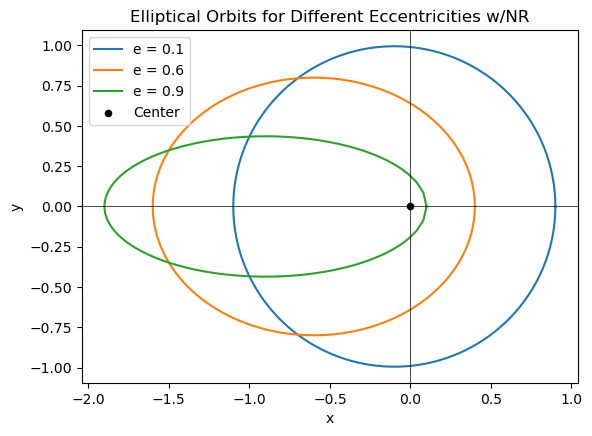

In [28]:
eccentricities = [0.1, 0.6, 0.9]
a = 1.0
P = 1.0

t_vals = np.linspace(0, P, 300)

for e in eccentricities:
    x, y = solve_orbit(a, e, P, t_vals)
    plt.plot(x, y, label=f"e = {e}")

#Plot center for reference
plt.scatter(0, 0, color="black", s=20, label="Center")
plt.axhline(0, linewidth=0.5,color="black")
plt.axvline(0, linewidth=0.5,color="black")

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Elliptical Orbits for Different Eccentricities w/NR")
plt.legend()
plt.savefig("Elliptical_Orbits_NR", dpi=300)
plt.show()